# Online2 Solver Logs Analysis

Questo notebook visualizza i log prodotti dal scheduler (`online2`) a ogni esecuzione del solver.

Contiene:
- andamento del tempo medio di processing per richiesta e per batch
- un grafico stacked per ciascuna esecuzione del solver con assegnamenti, errori medi per slot e capacity levels

In [9]:
%matplotlib inline
import pathlib
import sys

cwd = pathlib.Path.cwd().resolve()
candidates = [cwd, cwd.parent]
for candidate in candidates:
    if (candidate / 'config.py').exists():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break

import matplotlib.pyplot as plt
import pandas as pd

import config
import importlib
import visualize_solver_logs as viz
importlib.reload(viz)
from visualize_solver_logs import (
    load_solver_logs,
    load_infeasibility_debug_logs,
    plot_processing_times,
    plot_solver_execution_stacked,
    plot_infeasibility_overview,
    plot_infeasibility_event,
    select_run_ids,
)


In [10]:
# Run selection options for stacked assignment plots
# all | first_per_slot | last_per_slot | all_for_slot
RUN_SELECTION_MODE = "first_per_slot"
TARGET_SLOT = None  # used only when RUN_SELECTION_MODE == "all_for_slot"

# Strict-infeasible debug event selection
# None => latest event
INFEASIBILITY_EVENT_ID = None

runs_df, assignments_df, slot_metrics_df = load_solver_logs(
    runs_file=config.SOLVER_RUNS_FILE,
    assignments_file=config.SOLVER_ASSIGNMENTS_FILE,
    slot_metrics_file=config.SOLVER_SLOT_METRICS_FILE,
    only_runs_with_assignments=True,
)
debug_df = load_infeasibility_debug_logs(config.SOLVER_INFEASIBLE_DEBUG_FILE)

selected_run_ids = select_run_ids(
    runs_df,
    mode=RUN_SELECTION_MODE,
    target_slot=TARGET_SLOT,
) if not runs_df.empty else []

print(f"runs: {len(runs_df)}")
print(f"assignments rows: {len(assignments_df)}")
print(f"slot metrics rows: {len(slot_metrics_df)}")
print(f"strict-infeasible debug events: {len(debug_df)}")
print(f"selected stacked plots: {len(selected_run_ids)}")

display(runs_df.head())
if not debug_df.empty:
    display(debug_df.tail(5))


runs: 112
assignments rows: 7599
slot metrics rows: 2688
strict-infeasible debug events: 59
selected stacked plots: 9


,run_id,current_slot,pending_batch_size,total_assignments,new_assignments,replanned_assignments,solver_status,solver_mode,lock_future_assignments,solver_start_ts,solver_end_ts,solver_elapsed_ms,avg_ms_per_new_request,avg_ms_per_assignment,batches_processed_after,total_scheduled_after
0,1777280661924-1,1,3,3,3,0,ok,dp,True,1.777281e+09,1.777281e+09,23.012366,7.670789,7.670789,1,3
1,1777280662047-1,1,3,3,3,0,ok,dp,True,1.777281e+09,1.777281e+09,18.674803,6.224934,6.224934,2,6
2,1777280662163-1,1,3,3,3,0,ok,dp,True,1.777281e+09,1.777281e+09,11.954507,3.984836,3.984836,3,9
3,1777280662279-1,1,3,3,3,0,ok,dp,True,1.777281e+09,1.777281e+09,12.849950,4.283317,4.283317,4,12
4,1777280662396-1,1,3,3,3,0,ok,dp,True,1.777281e+09,1.777281e+09,14.850031,4.950010,4.950010,5,15


,event_id,timestamp,current_slot,pending_batch_size,pending_request_details,strict_threshold,baseline_error_sum,baseline_request_count,baseline_average_error,min_strategy_error,...,max_possible_avg_error_pending_only,strict_infeasible_by_error_bound,strict_scheduled_pending_count,relaxed_scheduled_pending_count,relaxed_success,lock_future_assignments,future_assignment_count,future_slot_counts,future_assignment_details,all_active_slot_counts
54,1777282746734-8,1.777283e+09,8,3,143:10|142:11|141:16,4.0,547.5,112,4.888393,1.0,...,4.891304,True,0,3,True,True,64,8:18|9:10|10:10|11:10|12:1|13:4|14:7|15:3|16:1,76:8:8:Fast|77:8:10:Fast|78:8:12:Fast|79:8:13:...,1:10|2:8|3:14|4:10|5:12|6:10|7:13|8:18|9:10|10...
55,1777282755609-9,1.777283e+09,9,3,144:13|146:13|145:16,4.0,525.0,107,4.906542,1.0,...,4.909091,True,0,3,True,True,47,9:10|10:10|11:10|12:1|13:4|14:7|15:3|16:2,53:9:11:Fast|57:9:11:Fast|92:9:9:Fast|96:9:13:...,1:10|2:8|3:14|4:10|5:12|6:10|7:13|8:20|9:10|10...
56,1777282755731-9,1.777283e+09,9,3,148:12|149:12|147:16,4.0,535.0,109,4.908257,1.0,...,4.910714,True,0,3,True,True,50,9:10|10:10|11:10|12:1|13:6|14:7|15:3|16:3,53:9:11:Fast|57:9:11:Fast|92:9:9:Fast|96:9:13:...,1:10|2:8|3:14|4:10|5:12|6:10|7:13|8:20|9:10|10...
57,1777282755866-9,1.777283e+09,9,3,151:11|150:15|152:16,4.0,545.0,111,4.909910,1.0,...,4.912281,True,0,3,True,True,53,9:10|10:10|11:10|12:3|13:6|14:7|15:3|16:4,53:9:11:Fast|57:9:11:Fast|92:9:9:Fast|96:9:13:...,1:10|2:8|3:14|4:10|5:12|6:10|7:13|8:20|9:10|10...
58,1777282756001-9,1.777283e+09,9,3,153:14|154:15|155:16,4.0,550.0,112,4.910714,1.0,...,4.913043,True,0,3,True,True,56,9:11|10:10|11:10|12:3|13:6|14:7|15:4|16:5,53:9:11:Fast|57:9:11:Fast|92:9:9:Fast|96:9:13:...,1:10|2:8|3:14|4:10|5:12|6:10|7:13|8:20|9:11|10...


## 1) Tempo di processing del solver

Grafico unico richiesto: andamento di
- tempo medio per richiesta
- tempo totale per batch

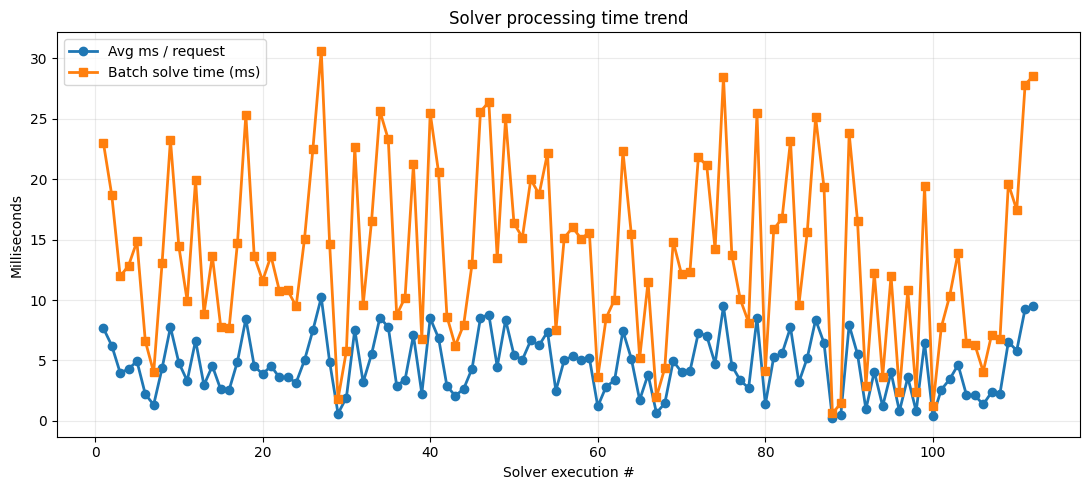

In [11]:
if runs_df.empty:
    print("Nessun dato disponibile in SOLVER_RUNS_FILE")
else:
    fig = plot_processing_times(runs_df)
    plt.show()

## 2) Assegnamenti per esecuzione solver (stacked bars)

Ogni grafico mostra **tutte** le richieste attive in quel run (non solo le N nuove).
Le richieste nuove del run sono evidenziate, quelle preesistenti sono più trasparenti.

Per mostrare un solo run per slot usa `RUN_SELECTION_MODE="first_per_slot"` (o `"last_per_slot"`).


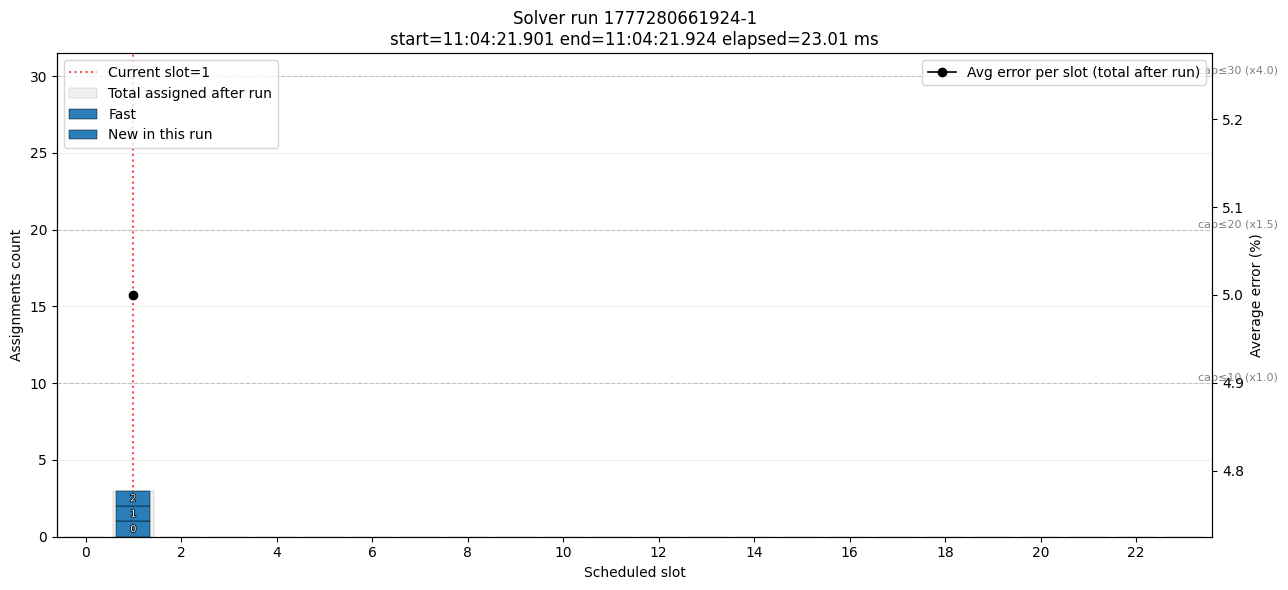

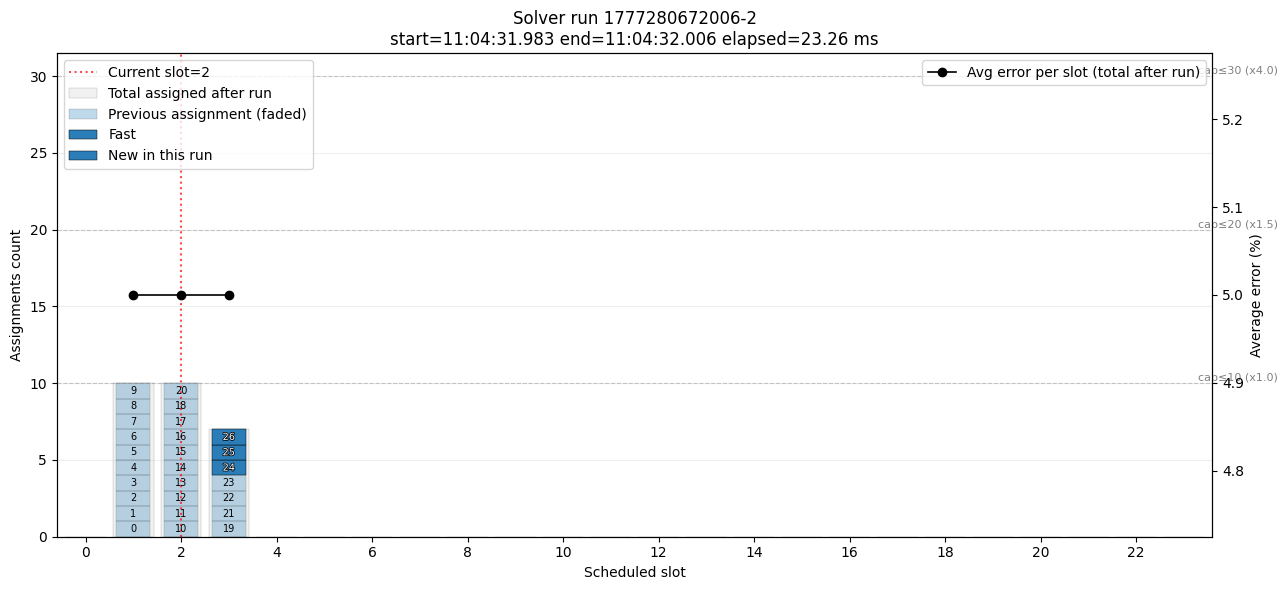

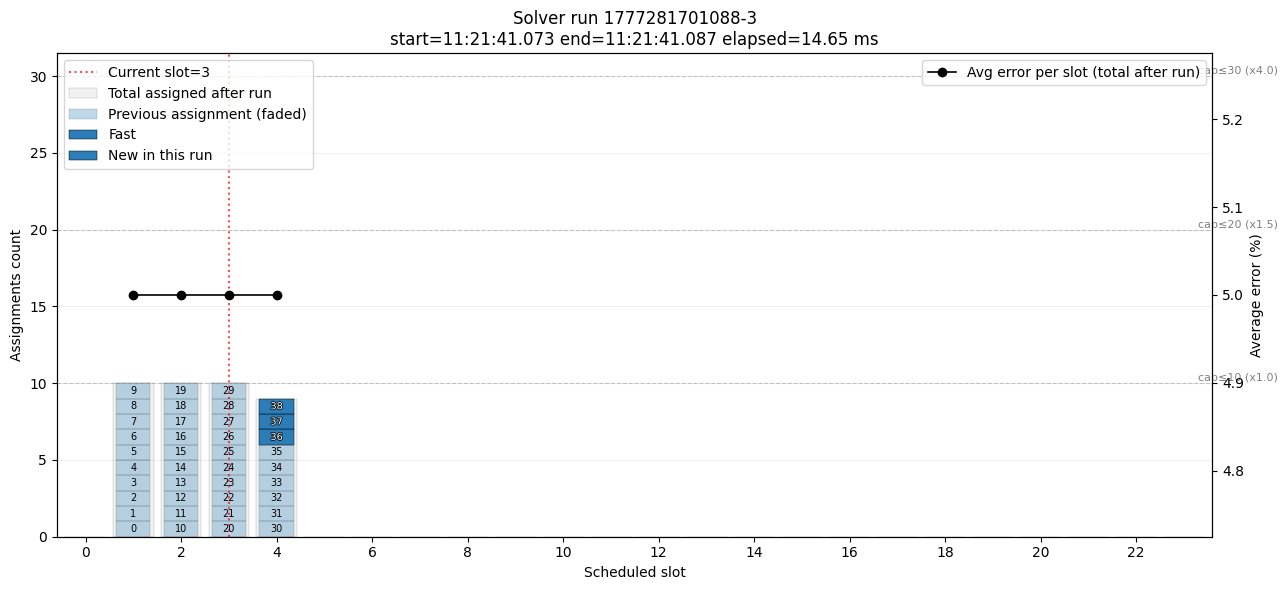

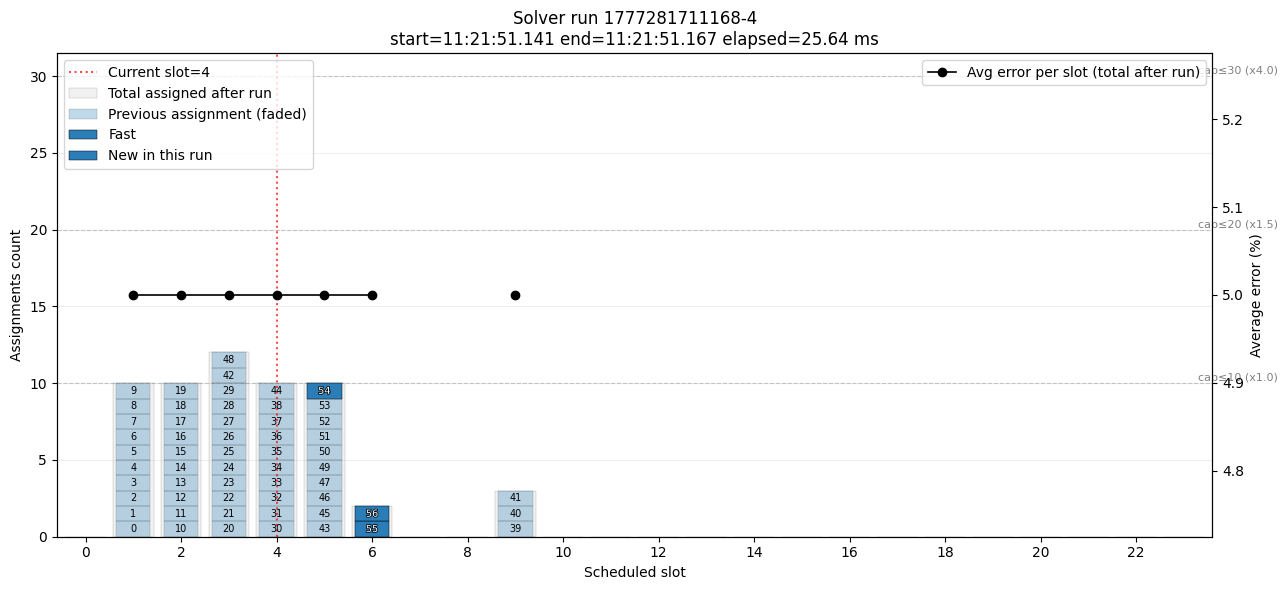

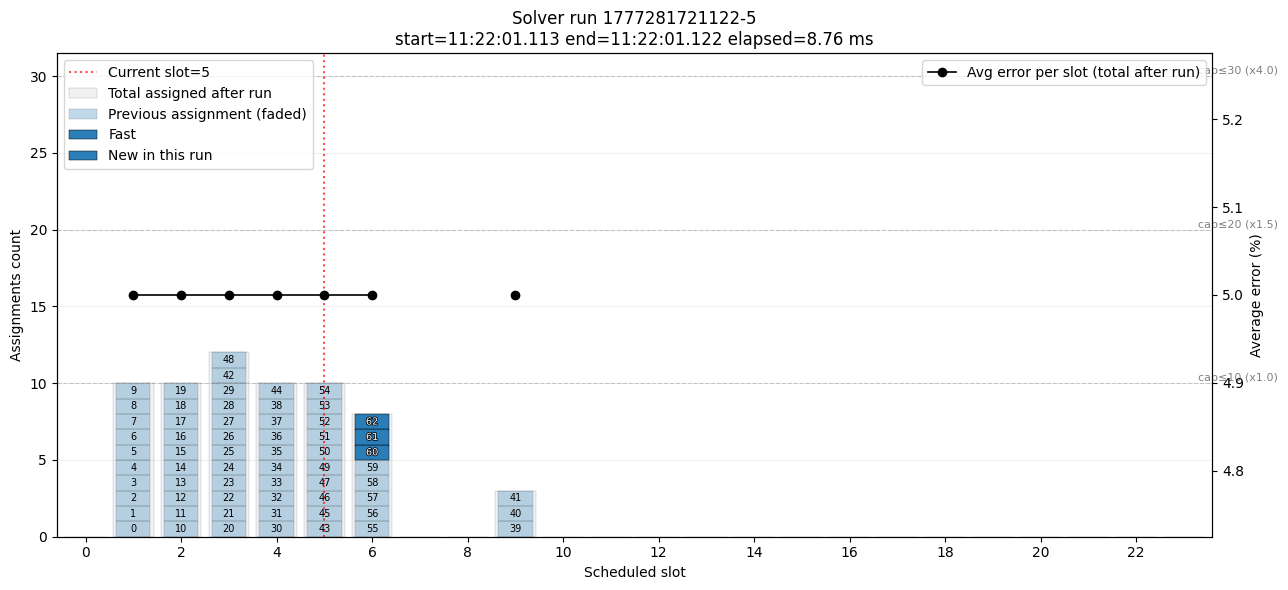

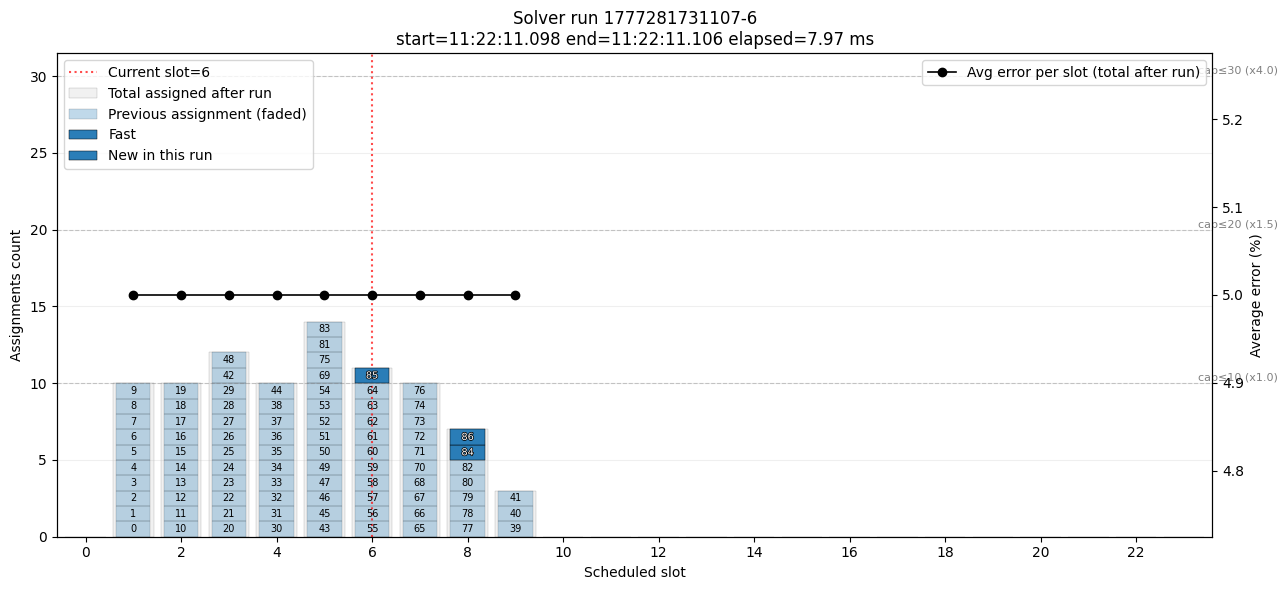

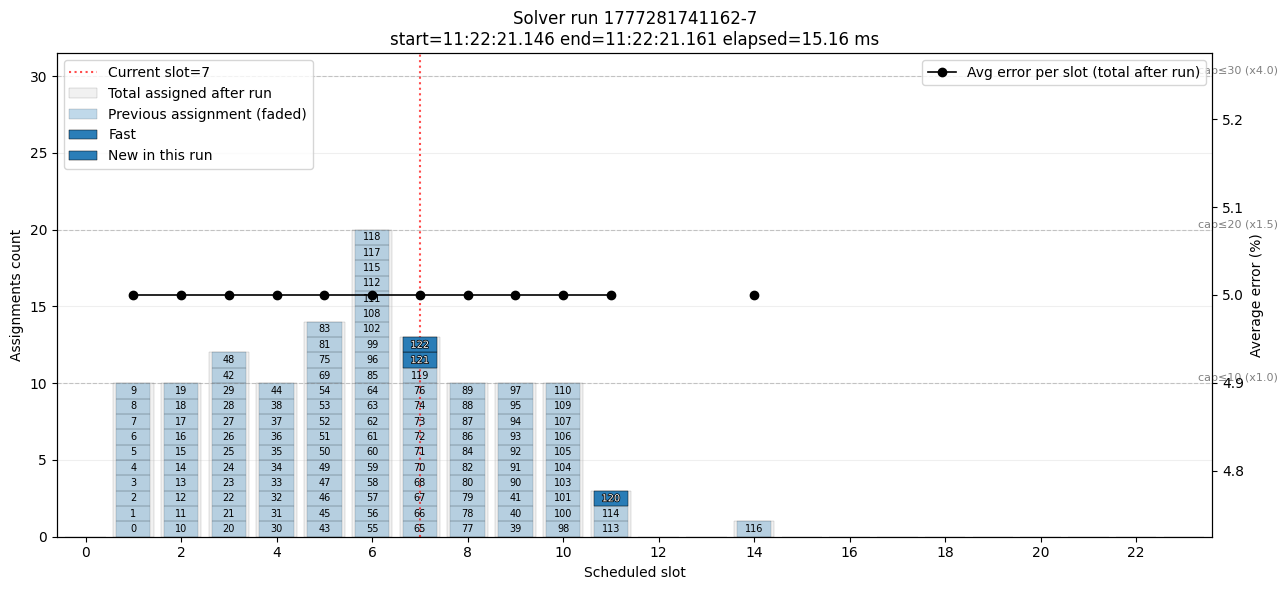

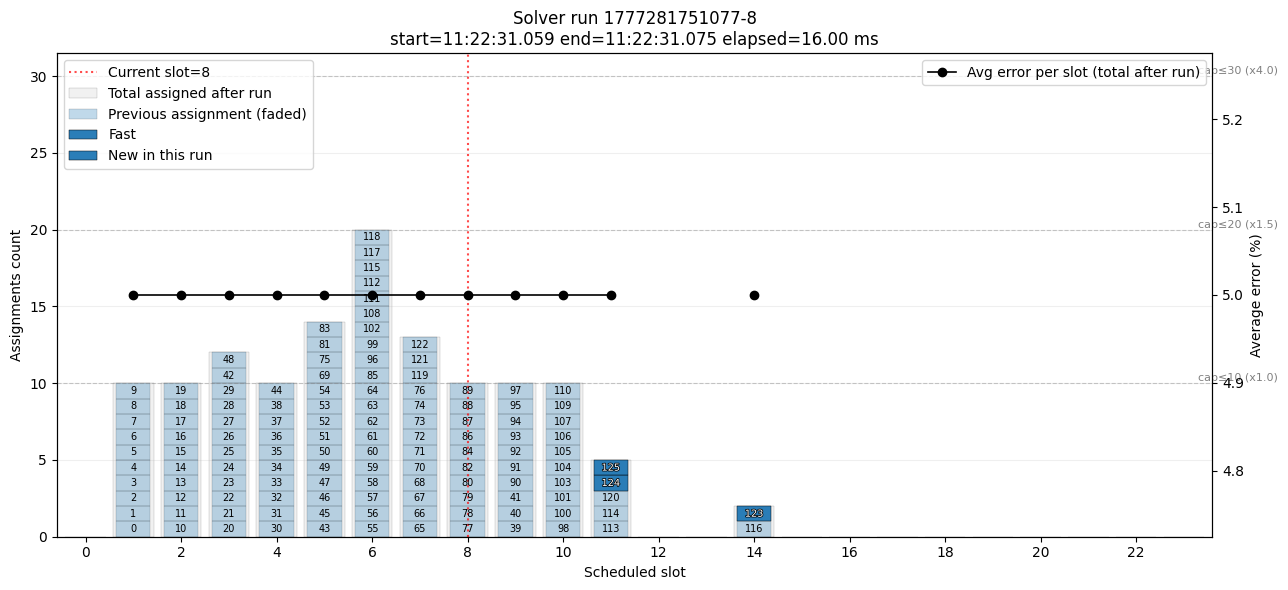

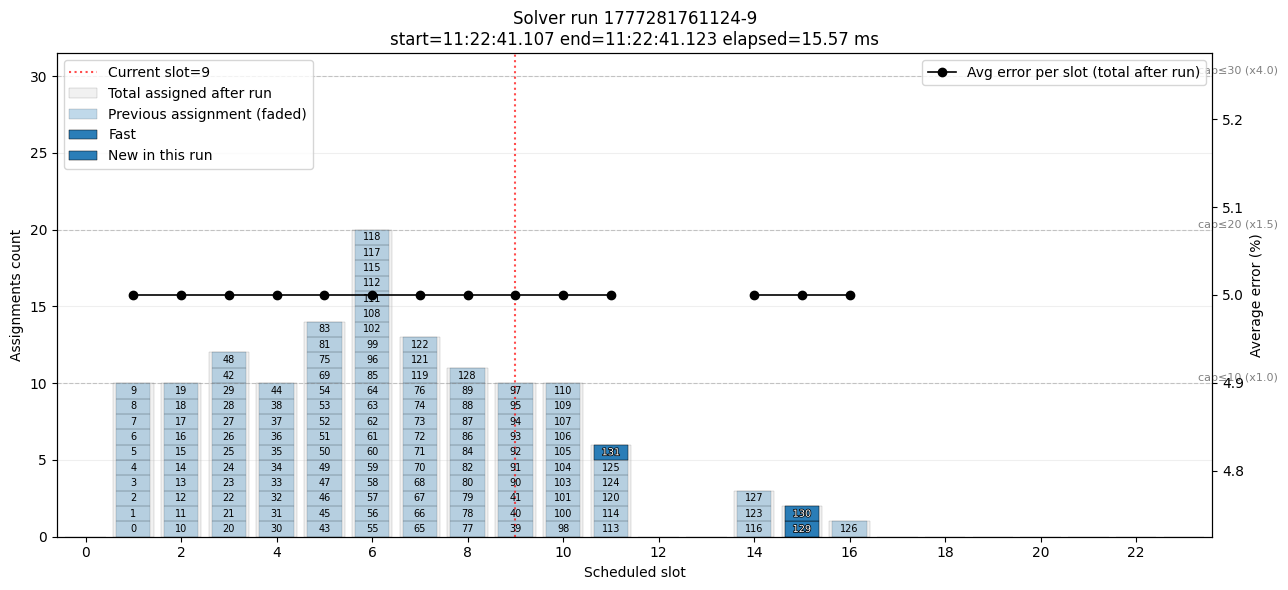

In [12]:
if runs_df.empty or assignments_df.empty:
    print("Dati insufficienti per i grafici stacked")
else:
    if not selected_run_ids:
        print("Nessun run selezionato con le opzioni correnti")
    for run_id in selected_run_ids:
        fig = plot_solver_execution_stacked(
            run_id=run_id,
            runs_df=runs_df,
            assignments_df=assignments_df,
            slot_metrics_df=slot_metrics_df,
        )
        plt.show()


## 3) Debug eventi di strict infeasibility

Questa sezione serve a capire quando il vincolo strict sulla finestra errore
non consente l'assegnamento completo e costringe al retry rilassato.


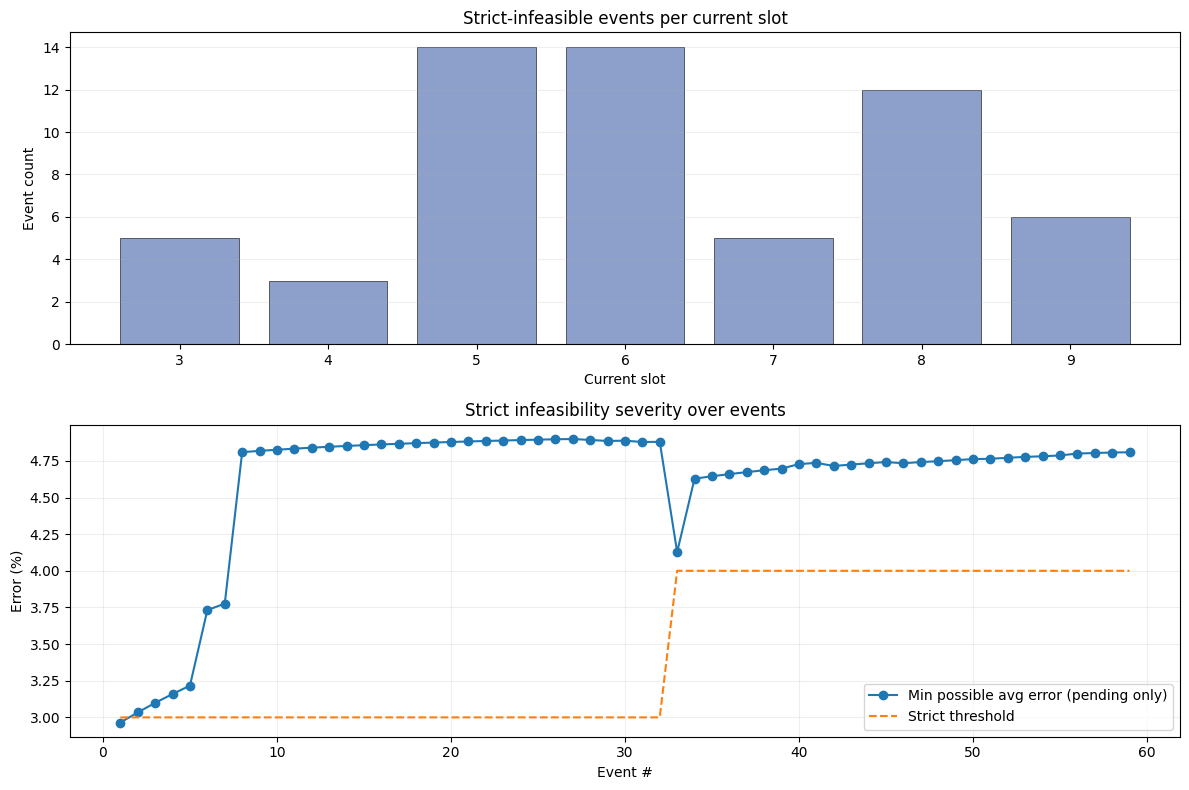

In [13]:
if debug_df.empty:
    print("Nessun evento strict-infeasible loggato")
else:
    fig = plot_infeasibility_overview(debug_df)
    plt.show()


,event_id,timestamp,current_slot,pending_batch_size,pending_request_details,strict_threshold,baseline_error_sum,baseline_request_count,baseline_average_error,min_strategy_error,...,max_possible_avg_error_pending_only,strict_infeasible_by_error_bound,strict_scheduled_pending_count,relaxed_scheduled_pending_count,relaxed_success,lock_future_assignments,future_assignment_count,future_slot_counts,future_assignment_details,all_active_slot_counts
55,1777282755609-9,1.777283e+09,9,3,144:13|146:13|145:16,4.0,525.0,107,4.906542,1.0,...,4.909091,True,0,3,True,True,47,9:10|10:10|11:10|12:1|13:4|14:7|15:3|16:2,53:9:11:Fast|57:9:11:Fast|92:9:9:Fast|96:9:13:...,1:10|2:8|3:14|4:10|5:12|6:10|7:13|8:20|9:10|10...


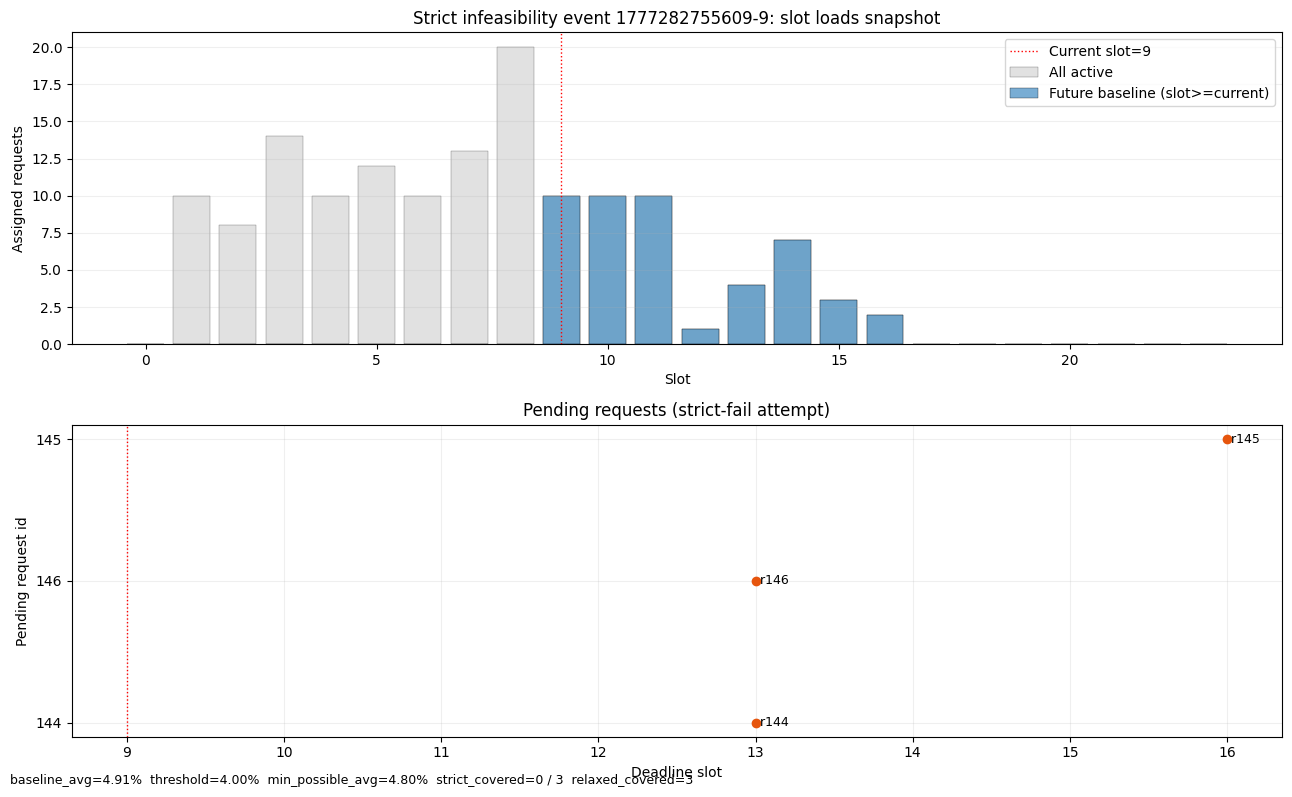

In [14]:
if debug_df.empty:
    print("Nessun evento strict-infeasible loggato")
else:
    selected_event_id = str(INFEASIBILITY_EVENT_ID) if INFEASIBILITY_EVENT_ID is not None else str(debug_df.iloc[-4]["event_id"])
    display(debug_df[debug_df["event_id"].astype(str) == selected_event_id])
    fig = plot_infeasibility_event(selected_event_id, debug_df)
    plt.show()


## Note

Se vuoi aggiornare i grafici, rilancia prima `python main.py --duration ...` e poi riesegui il notebook.